In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'pandas'

In [3]:
df = pd.read_csv('/Users/raghavendradivate/Desktop/Projects/majorP/Disease_and_symptoms_dataset.csv')

NameError: name 'pd' is not defined

In [3]:
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(246945, 378)

In [5]:
df.duplicated().sum()

np.int64(57298)

In [6]:
df.drop_duplicates()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246937,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246938,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246941,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246943,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
hip weakness                        0
back swelling                       0
ankle stiffness or tightness        0
ankle weakness                      0
neck weakness                       0
Length: 378, dtype: int64


In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
len(df['diseases'].unique())

773

In [10]:
disease_department_map = {
    'panic disorder': 'Psychiatry',
    'vocal cord polyp': 'ENT (Otorhinolaryngology)',
    'turner syndrome': 'Endocrinology',
    'cryptorchidism': 'Urology',
    'poisoning due to ethylene glycol': 'Emergency Medicine',
    'atrophic vaginitis': 'Obstetrics and Gynecology',
    'fracture of the hand': 'Orthopedics',
    'cellulitis or abscess of mouth': 'Dentistry/Oral Surgery',
    'eye alignment disorder': 'Ophthalmology',
    'headache after lumbar puncture': 'Neurology',
    'pyloric stenosis': 'Gastroenterology',
    'salivary gland disorder': 'ENT (Otorhinolaryngology)',
    'osteochondrosis': 'Orthopedics',
    'injury to the knee': 'Orthopedics',
    'metabolic disorder': 'Endocrinology',
    'vaginitis': 'Obstetrics and Gynecology',
    'sick sinus syndrome': 'Cardiology',
    'tinnitus of unknown cause': 'ENT (Otorhinolaryngology)',
    'glaucoma': 'Ophthalmology',
    'eating disorder': 'Psychiatry',
    'transient ischemic attack': 'Neurology',
    'pyelonephritis': 'Nephrology',
    'rotator cuff injury': 'Orthopedics',
    'chronic pain disorder': 'Pain Management/Physical Medicine',
    'problem during pregnancy': 'Obstetrics and Gynecology',
    'liver cancer': 'Oncology/Hepatology',
    'atelectasis': 'Pulmonology',
    'injury to the hand': 'Orthopedics',
    'choledocholithiasis': 'Gastroenterology',
    'injury to the hip': 'Orthopedics',
    'cirrhosis': 'Hepatology',
    'thoracic aortic aneurysm': 'Cardiology',
    'subdural hemorrhage': 'Neurology',
    'diabetic retinopathy': 'Ophthalmology',
    'fibromyalgia': 'Rheumatology',
    'ischemia of the bowel': 'Gastroenterology',
    'fetal alcohol syndrome': 'Pediatrics/Genetics',
    'peritonitis': 'General Surgery',
    'injury to the abdomen': 'Emergency Medicine/General Surgery',
    'acute pancreatitis': 'Gastroenterology',
    'thrombophlebitis': 'Vascular Surgery',
    'asthma': 'Pulmonology',
    'foreign body in the vagina': 'Obstetrics and Gynecology',
    'restless leg syndrome': 'Neurology',
    'emphysema': 'Pulmonology',
    'cysticercosis': 'Infectious Diseases',
    'induced abortion': 'Obstetrics and Gynecology',
    'teething syndrome': 'Pediatrics/Dentistry',
    'infectious gastroenteritis': 'Gastroenterology',
    'acute sinusitis': 'ENT (Otorhinolaryngology)',
    'substance-related mental disorder': 'Psychiatry',
    'postpartum depression': 'Psychiatry/Obstetrics',
    'coronary atherosclerosis': 'Cardiology',
    'spondylitis': 'Rheumatology/Orthopedics',
    'pituitary adenoma': 'Endocrinology/Neurosurgery',
    'uterine fibroids': 'Obstetrics and Gynecology',
    'idiopathic nonmenstrual bleeding': 'Obstetrics and Gynecology',
    'chalazion': 'Ophthalmology',
    'ovarian torsion': 'Obstetrics and Gynecology',
    'retinopathy due to high blood pressure': 'Ophthalmology',
    'vaginal yeast infection': 'Obstetrics and Gynecology',
    'mastoiditis': 'ENT (Otorhinolaryngology)',
    'lung contusion': 'Pulmonology',
    'hypertrophic obstructive cardiomyopathy (hocm)': 'Cardiology',
    'ingrown toe nail': 'Dermatology/General Surgery',
    'pulmonary eosinophilia': 'Pulmonology',
    'corneal disorder': 'Ophthalmology',
    'foreign body in the gastrointestinal tract': 'Gastroenterology',
    'endophthalmitis': 'Ophthalmology',
    'intestinal malabsorption': 'Gastroenterology',
    'viral warts': 'Dermatology',
    'hyperhidrosis': 'Dermatology',
    'stroke': 'Neurology',
    'pilonidal cyst': 'General Surgery',
    'crushing injury': 'Orthopedics',
    'normal pressure hydrocephalus': 'Neurology',
    'alopecia': 'Dermatology',
    'hashimoto thyroiditis': 'Endocrinology',
    'flat feet': 'Orthopedics/Podiatry',
    'nonalcoholic liver disease (nash)': 'Hepatology',
    'hemarthrosis': 'Hematology/Orthopedics',
    'pelvic organ prolapse': 'Obstetrics and Gynecology',
    'fracture of the arm': 'Orthopedics',
    'coagulation (bleeding) disorder': 'Hematology',
    'intracranial hemorrhage': 'Neurology',
    'hyperkalemia': 'Nephrology',
    'cornea infection': 'Ophthalmology',
    'abscess of the lung': 'Pulmonology',
    'dengue fever': 'Infectious Diseases',
    'chronic sinusitis': 'ENT (Otorhinolaryngology)',
    'cholesteatoma': 'ENT (Otorhinolaryngology)',
    'volvulus': 'General Surgery',
    'injury to the finger': 'Orthopedics',
    'poisoning due to analgesics': 'Emergency Medicine',
    'atrial fibrillation': 'Cardiology',
    'pinworm infection': 'Infectious Diseases',
    'urethral valves': 'Urology',
    'open wound of the neck': 'Emergency Medicine/Surgery',
    'achalasia': 'Gastroenterology',
    'conductive hearing loss': 'ENT (Otorhinolaryngology)',
    'abdominal hernia': 'General Surgery',
    'cerebral palsy': 'Neurology',
    'marijuana abuse': 'Psychiatry',
    'cryptococcosis': 'Infectious Diseases',
    'obesity': 'General Medicine',
    'indigestion': 'Gastroenterology',
    'bursitis': 'Orthopedics',
    'esophageal cancer': 'Oncology/Gastroenterology',
    'pulmonary congestion': 'Pulmonology',
    'juvenile rheumatoid arthritis': 'Rheumatology/Pediatrics',
    'actinic keratosis': 'Dermatology',
    'acute otitis media': 'ENT (Otorhinolaryngology)',
    'astigmatism': 'Ophthalmology',
    'tuberous sclerosis': 'Neurology',
    'empyema': 'Pulmonology/Infectious Diseases',
    'presbyacusis': 'ENT (Otorhinolaryngology)',
    'neonatal jaundice': 'Pediatrics/Neonatology',
    'chronic obstructive pulmonary disease (copd)': 'Pulmonology',
    'dislocation of the elbow': 'Orthopedics',
    'spondylosis': 'Orthopedics',
    'herpangina': 'Pediatrics/Infectious Diseases',
    'injury to the shoulder': 'Orthopedics',
    'poisoning due to antidepressants': 'Emergency Medicine',
    'infection of open wound': 'Infectious Diseases',
    'deep vein thrombosis (dvt)': 'Vascular Surgery',
    'protein deficiency': 'General Medicine',
    'myoclonus': 'Neurology',
    'bone spur of the calcaneous': 'Orthopedics',
    'von willebrand disease': 'Hematology',
    'open wound of the back': 'Emergency Medicine/Surgery',
    'heart block': 'Cardiology',
    'colonic polyp': 'Gastroenterology',
    'magnesium deficiency': 'General Medicine',
    'female infertility of unknown cause': 'Obstetrics and Gynecology',
    'pericarditis': 'Cardiology',
    'attention deficit hyperactivity disorder (adhd)': 'Psychiatry/Pediatrics',
    'pulmonic valve disease': 'Cardiology',
    'tietze syndrome': 'Rheumatology',
    'cranial nerve palsy': 'Neurology',
    'injury to the arm': 'Orthopedics',
    'conversion disorder': 'Psychiatry',
    'complex regional pain syndrome': 'Pain Management/Neurology',
    'otosclerosis': 'ENT (Otorhinolaryngology)',
    'injury to the trunk': 'Orthopedics',
    'hypothyroidism': 'Endocrinology',
    'primary insomnia': 'Psychiatry',
    'lice': 'Dermatology',
    'vitamin b12 deficiency': 'Hematology',
    'diabetes': 'Endocrinology',
    'vulvodynia': 'Obstetrics and Gynecology',
    'endometriosis': 'Obstetrics and Gynecology',
    'vasculitis': 'Rheumatology',
    'concussion': 'Neurology',
    'oral leukoplakia': 'Dentistry/Oral Surgery',
    'chronic kidney disease': 'Nephrology',
    'bladder disorder': 'Urology',
    'chorioretinitis': 'Ophthalmology/Infectious Diseases',
    'priapism': 'Urology',
    'myositis': 'Rheumatology',
    'mononucleosis': 'Infectious Diseases',
    'neuralgia': 'Neurology/Pain Management',
    'polycystic kidney disease': 'Nephrology',
    'bipolar disorder': 'Psychiatry',
    'amyloidosis': 'Hematology/Immunology',
    'chronic inflammatory demyelinating polyneuropathy (cidp)': 'Neurology',
    'gastroesophageal reflux disease (gerd)': 'Gastroenterology',
    'vitreous hemorrhage': 'Ophthalmology',
    'poisoning due to antimicrobial drugs': 'Emergency Medicine',
    'open wound of the mouth': 'Dentistry/Oral Surgery',
    'scleroderma': 'Rheumatology',
    'myasthenia gravis': 'Neurology',
    'hypoglycemia': 'Endocrinology',
    'idiopathic absence of menstruation': 'Obstetrics and Gynecology',
    'dislocation of the ankle': 'Orthopedics',
    'carbon monoxide poisoning': 'Emergency Medicine',
    'panic attack': 'Psychiatry',
    'plantar fasciitis': 'Orthopedics/Podiatry',
    'hyperopia': 'Ophthalmology',
    'poisoning due to sedatives': 'Emergency Medicine',
    'pemphigus': 'Dermatology',
    'peyronie disease': 'Urology',
    'hiatal hernia': 'Gastroenterology',
    'extrapyramidal effect of drugs': 'Neurology/Psychiatry',
    'meniere disease': 'ENT (Otorhinolaryngology)',
    'anal fissure': 'General Surgery/Proctology',
    'allergy': 'Allergy and Immunology',
    'chronic otitis media': 'ENT (Otorhinolaryngology)',
    'fracture of the finger': 'Orthopedics',
    'hirschsprung disease': 'Pediatrics/Surgery',
    'polymyalgia rheumatica': 'Rheumatology',
    'lymphedema': 'Vascular Surgery/Oncology',
    'bladder cancer': 'Urology',
    'acute bronchospasm': 'Pulmonology',
    'acute glaucoma': 'Ophthalmology',
    'open wound of the chest': 'Emergency Medicine/Surgery',
    'dislocation of the patella': 'Orthopedics',
    'sciatica': 'Orthopedics/Neurology',
    'hypercalcemia': 'Endocrinology/Oncology',
    'stress incontinence': 'Urology',
    'varicose veins': 'Vascular Surgery',
    'benign kidney cyst': 'Nephrology',
    'hydrocele of the testicle': 'Urology',
    'degenerative disc disease': 'Orthopedics',
    'hirsutism': 'Endocrinology/Dermatology',
    'dislocation of the foot': 'Orthopedics',
    'hydronephrosis': 'Urology',
    'diverticulosis': 'Gastroenterology',
    'pain after an operation': 'Pain Management',
    'huntington disease': 'Neurology',
    'lymphoma': 'Oncology/Hematology',
    'dermatitis due to sun exposure': 'Dermatology',
    'anemia due to chronic kidney disease': 'Nephrology',
    'injury to internal organ': 'Emergency Medicine/Trauma Surgery',
    'scleritis': 'Ophthalmology',
    'pterygium': 'Ophthalmology',
    'fungal infection of the skin': 'Dermatology',
    'insulin overdose': 'Emergency Medicine/Endocrinology',
    'syndrome of inappropriate secretion of adh (siadh)': 'Endocrinology',
    'foreign body in the ear': 'ENT (Otorhinolaryngology)',
    'premenstrual tension syndrome': 'Obstetrics and Gynecology',
    'orbital cellulitis': 'Ophthalmology/Infectious Diseases',
    'injury to the leg': 'Orthopedics',
    'hepatic encephalopathy': 'Hepatology',
    'bone cancer': 'Oncology/Orthopedics',
    'syringomyelia': 'Neurology',
    'pulmonary fibrosis': 'Pulmonology',
    'mitral valve disease': 'Cardiology',
    'parkinson disease': 'Neurology',
    'gout': 'Rheumatology',
    'otitis media': 'ENT (Otorhinolaryngology)',
    'drug abuse (opioids)': 'Psychiatry',
    'myelodysplastic syndrome': 'Hematology',
    'fracture of the shoulder': 'Orthopedics',
    'acute kidney injury': 'Nephrology',
    'threatened pregnancy': 'Obstetrics and Gynecology',
    'intracranial abscess': 'Neurology/Infectious Diseases',
    'gum disease': 'Dentistry',
    'open wound from surgical incision': 'Surgery',
    'gastrointestinal hemorrhage': 'Gastroenterology',
    'seborrheic dermatitis': 'Dermatology',
    'drug abuse (methamphetamine)': 'Psychiatry',
    'torticollis': 'Orthopedics/Neurology',
    'poisoning due to antihypertensives': 'Emergency Medicine',
    'tension headache': 'Neurology',
    'alcohol intoxication': 'Emergency Medicine',
    'scurvy': 'General Medicine',
    'narcolepsy': 'Neurology',
    'food allergy': 'Allergy and Immunology',
    'labyrinthitis': 'ENT (Otorhinolaryngology)',
    'anxiety': 'Psychiatry',
    'impulse control disorder': 'Psychiatry',
    'stenosis of the tear duct': 'Ophthalmology/ENT',
    'abscess of nose': 'ENT (Otorhinolaryngology)',
    'omphalitis': 'Pediatrics/Neonatology',
    'leukemia': 'Hematology/Oncology',
    'bell palsy': 'Neurology',
    'conjunctivitis due to allergy': 'Ophthalmology/Allergy',
    'drug reaction': 'Allergy and Immunology',
    'adrenal cancer': 'Oncology/Endocrinology',
    'myopia': 'Ophthalmology',
    'osteoarthritis': 'Orthopedics',
    'thyroid disease': 'Endocrinology',
    'pharyngitis': 'ENT (Otorhinolaryngology)',
    'chronic rheumatic fever': 'Cardiology/Rheumatology',
    'hypocalcemia': 'Endocrinology',
    'macular degeneration': 'Ophthalmology',
    'pneumonia': 'Pulmonology',
    'cold sore': 'Dermatology/Infectious Diseases',
    'premature ventricular contractions (pvcs)': 'Cardiology',
    'testicular cancer': 'Oncology/Urology',
    'hydrocephalus': 'Neurology/Neurosurgery',
    'breast cancer': 'Oncology',
    'anemia due to malignancy': 'Hematology/Oncology',
    'esophageal varices': 'Gastroenterology/Hepatology',
    'endometrial cancer': 'Oncology/Obstetrics and Gynecology',
    'cystic fibrosis': 'Pulmonology/Pediatrics',
    'intertrigo (skin condition)': 'Dermatology',
    'parathyroid adenoma': 'Endocrinology/Surgery',
    'glucocorticoid deficiency': 'Endocrinology',
    'temporomandibular joint disorder': 'Dentistry/Orthopedics',
    'wilson disease': 'Hepatology/Neurology',
    'vesicoureteral reflux': 'Urology/Pediatrics',
    'vitamin a deficiency': 'Nutrition/Endocrinology',
    'gonorrhea': 'Infectious Diseases/Urology',
    'fracture of the rib': 'Orthopedics',
    'ependymoma': 'Neurology/Neurosurgery',
    'hepatitis due to a toxin': 'Hepatology',
    'vaginal cyst': 'Obstetrics and Gynecology',
    'open wound of the shoulder': 'Emergency Medicine/Orthopedics',
    'ectopic pregnancy': 'Obstetrics and Gynecology',
    'chronic knee pain': 'Orthopedics/Pain Management',
    'pinguecula': 'Ophthalmology',
    'hypergammaglobulinemia': 'Immunology/Hematology',
    'alcohol abuse': 'Psychiatry',
    'carpal tunnel syndrome': 'Neurology/Orthopedics',
    'pituitary disorder': 'Endocrinology/Neurosurgery',
    'kidney stone': 'Urology',
    'autism': 'Psychiatry/Neurology/Pediatrics',
    'cat scratch disease': 'Infectious Diseases',
    'chronic glaucoma': 'Ophthalmology',
    'retinal detachment': 'Ophthalmology',
    'aplastic anemia': 'Hematology',
    'overflow incontinence': 'Urology',
    'hemolytic anemia': 'Hematology',
    'lateral epicondylitis (tennis elbow)': 'Orthopedics',
    'open wound of the eye': 'Ophthalmology/Emergency Medicine',
    'syphilis': 'Infectious Diseases',
    'diabetic kidney disease': 'Nephrology',
    'nose disorder': 'ENT (Otorhinolaryngology)',
    'drug withdrawal': 'Psychiatry',
    'dental caries': 'Dentistry',
    'hypercholesterolemia': 'Cardiology/Endocrinology',
    'fracture of the patella': 'Orthopedics',
    'kidney failure': 'Nephrology',
    'fracture of the neck': 'Orthopedics',
    'muscle spasm': 'Physical Medicine and Rehabilitation',
    'hemophilia': 'Hematology',
    'hyperosmotic hyperketotic state': 'Endocrinology',
    'peritonsillar abscess': 'ENT (Otorhinolaryngology)',
    'gastroparesis': 'Gastroenterology',
    'itching of unknown cause': 'Dermatology',
    'polycythemia vera': 'Hematology',
    'thrombocytopenia': 'Hematology',
    'head and neck cancer': 'Oncology/ENT (Otorhinolaryngology)',
    'pseudohypoparathyroidism': 'Endocrinology',
    'goiter': 'Endocrinology',
    'urge incontinence': 'Urology',
    'edward syndrome': 'Genetics/Pediatrics',
    'open wound of the arm': 'Emergency Medicine/Orthopedics',
    'muscular dystrophy': 'Neurology',
    'mittelschmerz': 'Obstetrics and Gynecology',
    'corneal abrasion': 'Ophthalmology',
    'anemia of chronic disease': 'Hematology/Internal Medicine',
    'dysthymic disorder': 'Psychiatry',
    'scarlet fever': 'Pediatrics/Infectious Diseases',
    'hypertensive heart disease': 'Cardiology',
    'drug abuse (barbiturates)': 'Psychiatry',
    'polycystic ovarian syndrome (pcos)': 'Endocrinology/Obstetrics and Gynecology',
    'encephalitis': 'Neurology/Infectious Diseases',
    'cyst of the eyelid': 'Ophthalmology',
    'balanitis': 'Urology',
    'foreign body in the throat': 'ENT (Otorhinolaryngology)',
    'drug abuse (cocaine)': 'Psychiatry',
    'optic neuritis': 'Neurology/Ophthalmology',
    'alcohol withdrawal': 'Psychiatry',
    'premature atrial contractions (pacs)': 'Cardiology',
    'hemiplegia': 'Neurology',
    'hammer toe': 'Orthopedics/Podiatry',
    'open wound of the cheek': 'Emergency Medicine/Oral Surgery',
    'joint effusion': 'Rheumatology/Orthopedics',
    'open wound of the knee': 'Emergency Medicine/Orthopedics',
    'meningioma': 'Neurology/Neurosurgery',
    'brain cancer': 'Oncology/Neurology/Neurosurgery',
    'placental abruption': 'Obstetrics and Gynecology',
    'seasonal allergies (hay fever)': 'Allergy and Immunology',
    'lung cancer': 'Oncology/Pulmonology',
    'primary kidney disease': 'Nephrology',
    'uterine cancer': 'Oncology/Obstetrics and Gynecology',
    'dry eye of unknown cause': 'Ophthalmology',
    'fibrocystic breast disease': 'Oncology/Breast Surgery',
    'fungal infection of the hair': 'Dermatology',
    'tooth abscess': 'Dentistry/Oral Surgery',
    'envenomation from spider or animal bite': 'Emergency Medicine/Toxicology',
    'vacterl syndrome': 'Genetics/Pediatrics',
    'vertebrobasilar insufficiency': 'Neurology',
    'rectal disorder': 'General Surgery/Colorectal Surgery',
    'atonic bladder': 'Urology',
    'benign paroxysmal positional vertical (bppv)': 'Neurology/Otolaryngology',
    'blepharospasm': 'Neurology/Ophthalmology',
    'sarcoidosis': 'Pulmonology/Rheumatology',
    'metastatic cancer': 'Oncology',
    'trigger finger (finger disorder)': 'Orthopedics',
    'stye': 'Ophthalmology',
    'hemochromatosis': 'Hematology/Internal Medicine',
    'osteochondroma': 'Orthopedics',
    'cushing syndrome': 'Endocrinology',
    'typhoid fever': 'Infectious Diseases',
    'vitreous degeneration': 'Ophthalmology',
    'atrophic skin condition': 'Dermatology',
    'aspergillosis': 'Infectious Diseases/Pulmonology',
    'uterine atony': 'Obstetrics and Gynecology',
    'trichinosis': 'Infectious Diseases',
    'whooping cough': 'Infectious Diseases/Pediatrics',
    'open wound of the lip': 'Emergency Medicine/Oral Surgery',
    'subacute thyroiditis': 'Endocrinology',
    'oral mucosal lesion': 'Dentistry/Oral Surgery',
    'open wound due to trauma': 'Emergency Medicine/Trauma Surgery',
    'intracerebral hemorrhage': 'Neurology/Neurosurgery',
    'alzheimer disease': 'Neurology',
    'vaginismus': 'Obstetrics and Gynecology/Psychiatry',
    'systemic lupus erythematosis (sle)': 'Rheumatology',
    'premature ovarian failure': 'Endocrinology/Obstetrics and Gynecology',
    'thoracic outlet syndrome': 'Neurology/Orthopedics',
    'ganglion cyst': 'Orthopedics',
    'dislocation of the knee': 'Orthopedics',
    'crohn disease': 'Gastroenterology',
    'postoperative infection': 'Infectious Diseases/Surgery',
    'folate deficiency': 'Hematology/Nutrition',
    'fluid overload': 'Nephrology/Cardiology',
    'atrial flutter': 'Cardiology',
    'skin disorder': 'Dermatology',
    'floaters': 'Ophthalmology',
    'tooth disorder': 'Dentistry',
    'heart attack': 'Cardiology',
    'open wound of the abdomen': 'Emergency Medicine/General Surgery',
    'fracture of the leg': 'Orthopedics',
    'oral thrush (yeast infection)': 'Dentistry/Infectious Diseases',
    'pityriasis rosea': 'Dermatology',
    'allergy to animals': 'Allergy and Immunology',
    'orthostatic hypotension': 'Cardiology',
    'obstructive sleep apnea (osa)': 'Pulmonology/Sleep Medicine',
    'hypokalemia': 'Nephrology/Internal Medicine',
    'psoriasis': 'Dermatology',
    'dislocation of the shoulder': 'Orthopedics',
    'intussusception': 'Pediatrics/Surgery',
    'cervicitis': 'Obstetrics and Gynecology',
    'abscess of the pharynx': 'ENT (Otorhinolaryngology)',
    'primary thrombocythemia': 'Hematology',
    'arthritis of the hip': 'Orthopedics/Rheumatology',
    'decubitus ulcer': 'Wound Care/Physical Medicine',
    'hypernatremia': 'Nephrology/Internal Medicine',
    'sensorineural hearing loss': 'ENT (Otorhinolaryngology)',
    'chronic ulcer': 'Wound Care/Dermatology',
    'osteoporosis': 'Endocrinology/Rheumatology',
    'ileus': 'General Surgery',
    'sickle cell crisis': 'Hematology',
    'urethritis': 'Urology',
    'prostatitis': 'Urology',
    "otitis externa (swimmer's ear)": 'ENT (Otorhinolaryngology)',
    'poisoning due to anticonvulsants': 'Emergency Medicine',
    'testicular torsion': 'Urology',
    'tricuspid valve disease': 'Cardiology',
    'urethral stricture': 'Urology',
    'vitamin d deficiency': 'Endocrinology',
    'hydatidiform mole': 'Obstetrics and Gynecology',
    'pain disorder affecting the neck': 'Pain Management/Neurology',
    'tuberculosis': 'Infectious Diseases/Pulmonology',
    'pelvic fistula': 'General Surgery/Obstetrics and Gynecology',
    'acute bronchiolitis': 'Pediatrics/Pulmonology',
    'presbyopia': 'Ophthalmology',
    'dementia': 'Neurology/Psychiatry',
    'insect bite': 'Dermatology',
    'paroxysmal ventricular tachycardia': 'Cardiology',
    'congenital heart defect': 'Pediatrics/Cardiology',
    'connective tissue disorder': 'Rheumatology',
    'foreign body in the eye': 'Ophthalmology/Emergency Medicine',
    'poisoning due to gas': 'Emergency Medicine',
    'pyogenic skin infection': 'Dermatology/Infectious Diseases',
    'endometrial hyperplasia': 'Obstetrics and Gynecology',
    'acanthosis nigricans': 'Endocrinology/Dermatology',
    'central atherosclerosis': 'Cardiology',
    'viral exanthem': 'Infectious Diseases/Dermatology',
    'noninfectious gastroenteritis': 'Gastroenterology',
    'benign prostatic hyperplasia (bph)': 'Urology',
    'menopause': 'Obstetrics and Gynecology',
    'primary immunodeficiency': 'Immunology',
    'ovarian cancer': 'Oncology/Obstetrics and Gynecology',
    'cataract': 'Ophthalmology',
    'dislocation of the hip': 'Orthopedics',
    'spinal stenosis': 'Orthopedics/Neurology',
    'intestinal obstruction': 'General Surgery',
    'heart contusion': 'Cardiology/Trauma Surgery',
    'congenital malformation syndrome': 'Genetics/Pediatrics',
    'sporotrichosis': 'Infectious Diseases/Dermatology',
    'lymphangitis': 'Infectious Diseases',
    'wernicke korsakoff syndrome': 'Neurology',
    'intestinal disease': 'Gastroenterology',
    'acute bronchitis': 'Pulmonology',
    'persistent vomiting of unknown cause': 'Gastroenterology',
    'open wound of the foot': 'Emergency Medicine/Orthopedics',
    'myocarditis': 'Cardiology',
    'preeclampsia': 'Obstetrics and Gynecology',
    'ischemic heart disease': 'Cardiology',
    'neurofibromatosis': 'Neurology/Genetics',
    'chickenpox': 'Infectious Diseases/Pediatrics',
    'pancreatic cancer': 'Oncology/Gastroenterology',
    'neuropathy due to drugs': 'Neurology',
    'croup': 'Pediatrics',
    'idiopathic excessive menstruation': 'Obstetrics and Gynecology',
    'amblyopia': 'Ophthalmology',
    'meckel diverticulum': 'General Surgery',
    'dislocation of the wrist': 'Orthopedics',
    'ear drum damage': 'ENT (Otorhinolaryngology)',
    'erectile dysfunction': 'Urology',
    'temporary or benign blood in urine': 'Urology',
    'kidney disease due to longstanding hypertension': 'Nephrology',
    'chondromalacia of the patella': 'Orthopedics',
    'onychomycosis': 'Dermatology',
    'urethral disorder': 'Urology',
    'lyme disease': 'Infectious Diseases',
    'iron deficiency anemia': 'Hematology',
    'acute respiratory distress syndrome (ards)': 'Pulmonology/Intensive Care',
    'toxic multinodular goiter': 'Endocrinology',
    'open wound of the finger': 'Emergency Medicine/Orthopedics',
    'autonomic nervous system disorder': 'Neurology',
    'psychosexual disorder': 'Psychiatry',
    'anemia': 'Hematology',
    'tendinitis': 'Orthopedics',
    'common cold': 'Pulmonology/Primary Care',
    'amyotrophic lateral sclerosis (als)': 'Neurology',
    'central retinal artery or vein occlusion': 'Ophthalmology/Neurology',
    'paroxysmal supraventricular tachycardia': 'Cardiology',
    'venous insufficiency': 'Vascular Surgery',
    'trichomonas infection': 'Infectious Diseases/Urology',
    'acne': 'Dermatology',
    'depression': 'Psychiatry',
    'drug abuse': 'Psychiatry',
    'urinary tract obstruction': 'Urology',
    'diabetes insipidus': 'Endocrinology',
    'iridocyclitis': 'Ophthalmology',
    'varicocele of the testicles': 'Urology',
    'irritable bowel syndrome': 'Gastroenterology',
    'fracture of the foot': 'Orthopedics',
    'ovarian cyst': 'Obstetrics and Gynecology',
    'chlamydia': 'Infectious Diseases/Urology',
    'parasitic disease': 'Infectious Diseases',
    'fracture of the jaw': 'Oral Surgery/Orthopedics',
    'lipoma': 'General Surgery/Dermatology',
    'female genitalia infection': 'Obstetrics and Gynecology',
    'pulmonary hypertension': 'Cardiology/Pulmonology',
    'thyroid nodule': 'Endocrinology',
    'broken tooth': 'Dentistry',
    'dumping syndrome': 'Gastroenterology',
    'lymphadenitis': 'Infectious Diseases',
    'injury to the face': 'Emergency Medicine/Oral Surgery',
    'aortic valve disease': 'Cardiology',
    'rheumatoid arthritis': 'Rheumatology',
    'spermatocele': 'Urology',
    'impetigo': 'Dermatology',
    'anal fistula': 'General Surgery/Proctology',
    'hypothermia': 'Emergency Medicine',
    'oppositional disorder': 'Psychiatry',
    'migraine': 'Neurology',
    'diabetic peripheral neuropathy': 'Endocrinology/Neurology',
    'testicular disorder': 'Urology',
    'gestational diabetes': 'Obstetrics and Gynecology/Endocrinology',
    'hidradenitis suppurativa': 'Dermatology',
    'valley fever': 'Infectious Diseases',
    'conjunctivitis due to bacteria': 'Ophthalmology/Infectious Diseases',
    'lewy body dementia': 'Neurology/Psychiatry',
    'multiple myeloma': 'Hematology/Oncology',
    'head injury': 'Emergency Medicine/Neurology',
    'ascending cholangitis': 'Gastroenterology/Surgery',
    'idiopathic irregular menstrual cycle': 'Obstetrics and Gynecology',
    'interstitial lung disease': 'Pulmonology',
    'mononeuritis': 'Neurology',
    'malaria': 'Infectious Diseases',
    'somatization disorder': 'Psychiatry',
    'hypovolemia': 'Emergency Medicine/Internal Medicine',
    'schizophrenia': 'Psychiatry',
    'knee ligament or meniscus tear': 'Orthopedics',
    'endocarditis': 'Cardiology/Infectious Diseases',
    'sepsis': 'Emergency Medicine/Infectious Diseases',
    'heat stroke': 'Emergency Medicine',
    'cholecystitis': 'General Surgery/Gastroenterology',
    'cardiac arrest': 'Emergency Medicine/Cardiology',
    'cardiomyopathy': 'Cardiology',
    'social phobia': 'Psychiatry',
    'meningitis': 'Neurology/Infectious Diseases',
    'spherocytosis': 'Hematology',
    'hormone disorder': 'Endocrinology',
    'raynaud disease': 'Rheumatology',
    'reactive arthritis': 'Rheumatology',
    'scabies': 'Dermatology',
    'ear wax impaction': 'ENT (Otorhinolaryngology)',
    'hypertension of pregnancy': 'Obstetrics and Gynecology',
    'peripheral arterial embolism': 'Vascular Surgery',
    'rosacea': 'Dermatology',
    'fracture of the skull': 'Neurosurgery/Orthopedics',
    'uveitis': 'Ophthalmology',
    'fracture of the facial bones': 'Trauma Surgery/Oral Surgery',
    'tracheitis': 'ENT (Otorhinolaryngology)',
    'jaw disorder': 'Dentistry/Orthopedics',
    'perirectal infection': 'General Surgery/Proctology',
    'breast cyst': 'Oncology/Breast Surgery',
    'post-traumatic stress disorder (ptsd)': 'Psychiatry',
    'kidney cancer': 'Oncology/Urology',
    'vulvar cancer': 'Oncology/Obstetrics and Gynecology',
    'blepharitis': 'Ophthalmology',
    'celiac disease': 'Gastroenterology',
    'cystitis': 'Urology',
    'sickle cell anemia': 'Hematology',
    'subconjunctival hemorrhage': 'Ophthalmology',
    'hemorrhoids': 'General Surgery/Proctology',
    'contact dermatitis': 'Dermatology',
    'sinus bradycardia': 'Cardiology',
    'high blood pressure': 'Cardiology/Internal Medicine',
    'pelvic inflammatory disease': 'Obstetrics and Gynecology',
    'liver disease': 'Hepatology',
    'chronic constipation': 'Gastroenterology',
    'thyroid cancer': 'Oncology/Endocrinology',
    'flu': 'Infectious Diseases',
    'friedrich ataxia': 'Neurology/Genetics',
    'tic (movement) disorder': 'Neurology',
    'skin polyp': 'Dermatology',
    'brachial neuritis': 'Neurology',
    'cervical cancer': 'Oncology/Obstetrics and Gynecology',
    'adrenal adenoma': 'Endocrinology',
    'esophagitis': 'Gastroenterology',
    'gas gangrene': 'Emergency Medicine/Infectious Diseases',
    'yeast infection': 'Obstetrics and Gynecology',
    'spina bifida': 'Neurology/Neurosurgery/Pediatrics',
    'drug poisoning due to medication': 'Emergency Medicine',
    'alcoholic liver disease': 'Hepatology',
    'malignant hypertension': 'Cardiology/Nephrology',
    'diverticulitis': 'Gastroenterology/General Surgery',
    'moyamoya disease': 'Neurology',
    'heat exhaustion': 'Emergency Medicine',
    'psychotic disorder': 'Psychiatry',
    'frostbite': 'Emergency Medicine',
    'atrophy of the corpus cavernosum': 'Urology',
    'smoking or tobacco addiction': 'Pulmonology/Psychiatry',
    'sprain or strain': 'Orthopedics',
    'essential tremor': 'Neurology',
    'open wound of the ear': 'ENT (Otorhinolaryngology)/Emergency Medicine',
    'foreign body in the nose': 'ENT (Otorhinolaryngology)',
    'idiopathic painful menstruation': 'Obstetrics and Gynecology',
    'down syndrome': 'Genetics/Pediatrics',
    'idiopathic infrequent menstruation': 'Obstetrics and Gynecology',
    'pneumothorax': 'Pulmonology',
    'de quervain disease': 'Orthopedics',
    'fracture of the vertebra': 'Orthopedics/Neurosurgery',
    'human immunodeficiency virus infection (hiv)': 'Infectious Diseases',
    'mumps': 'Infectious Diseases',
    'subarachnoid hemorrhage': 'Neurology/Neurosurgery',
    'acute fatty liver of pregnancy (aflp)': 'Obstetrics and Gynecology',
    'ectropion': 'Ophthalmology',
    'scar': 'Dermatology',
    'lactose intolerance': 'Gastroenterology',
    'eustachian tube dysfunction (ear disorder)': 'ENT (Otorhinolaryngology)',
    'appendicitis': 'General Surgery',
    'graves disease': 'Endocrinology',
    'dissociative disorder': 'Psychiatry',
    'open wound of the face': 'Emergency Medicine/Oral Surgery',
    'dislocation of the vertebra': 'Orthopedics/Neurosurgery',
    'phimosis': 'Urology',
    'hyperemesis gravidarum': 'Obstetrics and Gynecology',
    'pregnancy': 'Obstetrics and Gynecology',
    'thalassemia': 'Hematology',
    'placenta previa': 'Obstetrics and Gynecology',
    'epidural hemorrhage': 'Neurology/Neurosurgery',
    'septic arthritis': 'Rheumatology/Infectious Diseases',
    "athlete's foot": 'Dermatology',
    'pleural effusion': 'Pulmonology',
    'aphakia': 'Ophthalmology',
    'vulvar disorder': 'Obstetrics and Gynecology',
    'sialoadenitis': 'ENT (Otorhinolaryngology)',
    'gynecomastia': 'Endocrinology/Urology',
    'urinary tract infection': 'Urology/Infectious Diseases',
    'histoplasmosis': 'Infectious Diseases',
    'erythema multiforme': 'Dermatology',
    'scoliosis': 'Orthopedics',
    'bunion': 'Orthopedics/Podiatry',
    'arrhythmia': 'Cardiology',
    'trigeminal neuralgia': 'Neurology',
    'ankylosing spondylitis': 'Rheumatology',
    'peripheral nerve disorder': 'Neurology',
    'sebaceous cyst': 'Dermatology',
    'poisoning due to antipsychotics': 'Emergency Medicine',
    'neurosis': 'Psychiatry',
    'prostate cancer': 'Oncology/Urology',
    'cerebral edema': 'Neurology',
    'dislocation of the finger': 'Orthopedics',
    'birth trauma': 'Pediatrics/Obstetrics',
    'chronic pancreatitis': 'Gastroenterology',
    'hematoma': 'Emergency Medicine',
    'carcinoid syndrome': 'Oncology',
    'open wound of the head': 'Emergency Medicine/Neurosurgery',
    'seborrheic keratosis': 'Dermatology',
    'burn': 'Emergency Medicine/Dermatology',
    'spontaneous abortion': 'Obstetrics and Gynecology',
    'genital herpes': 'Infectious Diseases/Dermatology',
    'adjustment reaction': 'Psychiatry',
    'gallstone': 'Gastroenterology/Surgery',
    'multiple sclerosis': 'Neurology',
    'zenker diverticulum': 'General Surgery',
    'fracture of the pelvis': 'Orthopedics',
    'pneumoconiosis': 'Pulmonology',
    'hyperlipidemia': 'Cardiology/Endocrinology',
    'ulcerative colitis': 'Gastroenterology',
    'male genitalia infection': 'Urology/Infectious Diseases',
    'hpv': 'Dermatology/Infectious Diseases',
    'angina': 'Cardiology',
    'injury to the spinal cord': 'Neurology/Neurosurgery',
    'nasal polyp': 'ENT (Otorhinolaryngology)',
    'lichen simplex': 'Dermatology',
    'trichiasis': 'Ophthalmology',
    'acariasis': 'Dermatology',
    'colorectal cancer': 'Oncology/General Surgery',
    'skin pigmentation disorder': 'Dermatology',
    'factitious disorder': 'Psychiatry',
    'lymphogranuloma venereum': 'Infectious Diseases',
    'galactorrhea of unknown cause': 'Endocrinology',
    'g6pd enzyme deficiency': 'Hematology',
    'nerve impingement near the shoulder': 'Orthopedics/Neurology',
    'toxoplasmosis': 'Infectious Diseases',
    'fibroadenoma': 'Surgery/Breast Surgery',
    'open wound of the hand': 'Emergency Medicine/Orthopedics',
    'missed abortion': 'Obstetrics and Gynecology',
    'diabetic ketoacidosis': 'Endocrinology/Emergency Medicine',
    'granuloma inguinale': 'Infectious Diseases',
    'obsessive compulsive disorder (ocd)': 'Psychiatry',
    'injury of the ankle': 'Orthopedics',
    'hyponatremia': 'Nephrology/Internal Medicine',
    'stricture of the esophagus': 'Gastroenterology/Surgery',
    'fracture of the ankle': 'Orthopedics',
    'soft tissue sarcoma': 'Oncology/Surgery',
    'bone disorder': 'Endocrinology/Orthopedics',
    'epilepsy': 'Neurology',
    'personality disorder': 'Psychiatry',
    'shingles (herpes zoster)': 'Dermatology/Infectious Diseases',
    'tourette syndrome': 'Neurology/Psychiatry',
    'avascular necrosis': 'Orthopedics',
    'strep throat': 'ENT (Otorhinolaryngology)/Infectious Diseases',
    'spinocerebellar ataxia': 'Neurology',
    'osteomyelitis': 'Orthopedics/Infectious Diseases',
    'sjogren syndrome': 'Rheumatology',
    'adhesive capsulitis of the shoulder': 'Orthopedics/Physical Medicine',
    'viral hepatitis': 'Hepatology/Infectious Diseases',
    'tonsillar hypertrophy': 'ENT (Otorhinolaryngology)',
    'gastritis': 'Gastroenterology',
    'skin cancer': 'Dermatology/Oncology',
    'rheumatic fever': 'Cardiology/Rheumatology',
    'aphthous ulcer': 'Dentistry/Gastroenterology',
    'tonsillitis': 'ENT (Otorhinolaryngology)/Infectious Diseases',
    'intestinal cancer': 'Oncology/Gastroenterology',
    'rocky mountain spotted fever': 'Infectious Diseases',
    'stomach cancer': 'Oncology/Gastroenterology',
    'developmental disability': 'Pediatrics/Neurology',
    'acute stress reaction': 'Psychiatry',
    'delirium': 'Psychiatry/Neurology',
    'callus': 'Dermatology/Podiatry',
    'guillain barre syndrome': 'Neurology',
    'lumbago': 'Orthopedics/Neurology',
    'deviated nasal septum': 'ENT (Otorhinolaryngology)',
    'hemangioma': 'Dermatology/Pediatrics',
    'peripheral arterial disease': 'Vascular Surgery/Cardiology',
    'chronic back pain': 'Pain Management/Orthopedics',
    'heart failure': 'Cardiology',
    'conjunctivitis': 'Ophthalmology',
    'herniated disk': 'Orthopedics/Neurology',
    'rhabdomyolysis': 'Internal Medicine/Emergency Medicine',
    'breast infection (mastitis)': 'Obstetrics and Gynecology',
    'abdominal aortic aneurysm': 'Vascular Surgery',
    'pulmonary embolism': 'Pulmonology/Vascular Surgery',
    'conduct disorder': 'Psychiatry',
    'mastectomy': 'Oncology/Surgery',
    'epididymitis': 'Urology/Infectious Diseases',
    'premature rupture of amniotic membrane': 'Obstetrics and Gynecology',
    'molluscum contagiosum': 'Dermatology/Infectious Diseases',
    'necrotizing fasciitis': 'Emergency Medicine/Infectious Diseases',
    'benign vaginal discharge (leukorrhea)': 'Obstetrics and Gynecology',
    'bladder obstruction': 'Urology',
    'melanoma': 'Dermatology/Oncology',
    'cervical disorder': 'Obstetrics and Gynecology',
    'laryngitis': 'ENT (Otorhinolaryngology)',
    'dyshidrosis': 'Dermatology',
    'poisoning due to opioids': 'Emergency Medicine',
    'diaper rash': 'Pediatrics/Dermatology',
    'lichen planus': 'Dermatology',
    'gastroduodenal ulcer': 'Gastroenterology',
    'inguinal hernia': 'General Surgery',
    'eczema': 'Dermatology',
    'asperger syndrome': 'Psychiatry/Neurology',
    'mucositis': 'Oncology/Dermatology',
    'paronychia': 'Dermatology',
    'open wound of the jaw': 'Emergency Medicine/Oral Surgery',
    'white blood cell disease': 'Hematology',
    'kaposi sarcoma': 'Oncology/Infectious Diseases',
    'spondylolisthesis': 'Orthopedics',
    'pseudotumor cerebri': 'Neurology',
    'conjunctivitis due to virus': 'Ophthalmology/Infectious Diseases',
    'open wound of the nose': 'Emergency Medicine/ENT (Otorhinolaryngology)',
}


In [11]:
# Original disease_department_map with expanded General Medicine diseases reassigned
expanded_general_medicine_diseases = [
    'protein deficiency', 'magnesium deficiency', 'scurvy', 'obstructive sleep apnea (osa)',
    'hypertension', 'hyperlipidemia', 'diabetes', 'anemia', 'iron deficiency anemia',
    'vitamin b12 deficiency', 'vitamin d deficiency', 'vitamin a deficiency', 'hypokalemia',
    'hyperkalemia', 'hypoglycemia', 'fluid overload', 'obesity', 'indigestion', 'common cold',
    'orthostatic hypotension', 'dehydration', 'narcolepsy', 'electrolyte imbalance',
    'general fatigue', 'metabolic disorder', 'hypocalcemia', 'hypomagnesemia',
    'multiple vitamin deficiencies', 'sepsis', 'mild viral infections',
    'acute gastroenteritis', 'chronic fatigue syndrome'
]

for disease in expanded_general_medicine_diseases:
    disease_department_map[disease] = 'General Medicine'

In [12]:
# List or set of departments you want to keep
allowed_departments = {
    'general medicine',
    'neurology',
    'dermatology',
    'cardiology',
    'pulmonology',
    'gastroenterology',
    'infectious diseases',
    'orthopedics'
}

In [13]:
def dept_allowed(dept):
    # Normalize department string to lowercase and check if it's in allowed departments
    if not dept:
        return False
    dept_lower = dept.lower()
    return any(allowed == dept_lower or allowed in dept_lower for allowed in allowed_departments)


In [14]:
# Create boolean mask: keep rows whose disease maps to allowed department
mask = df['diseases'].apply(lambda d: dept_allowed(disease_department_map.get(d, '')))


In [15]:
# Filter DataFrame to keep only rows with diseases in allowed departments
filtered_df = df[mask].reset_index(drop=True)

In [16]:
print(f"Original rows count: {len(df)}")
print(f"Rows after filtering: {len(filtered_df)}")


Original rows count: 246945
Rows after filtering: 128771


In [17]:
len(filtered_df['diseases'].unique())

385

In [18]:
df = filtered_df

In [19]:
X = df.drop('diseases', axis=1)
y = df['diseases']

In [20]:

count_ones = (X == 1).sum()

print(count_ones)

anxiety and nervousness               629
depression                            912
shortness of breath                 15572
depressive or psychotic symptoms     4884
sharp chest pain                    17995
                                    ...  
hip weakness                            0
back swelling                           0
ankle stiffness or tightness            0
ankle weakness                         18
neck weakness                           0
Length: 377, dtype: int64


In [21]:
top_counts = count_ones.sort_values(ascending=False).head(50)

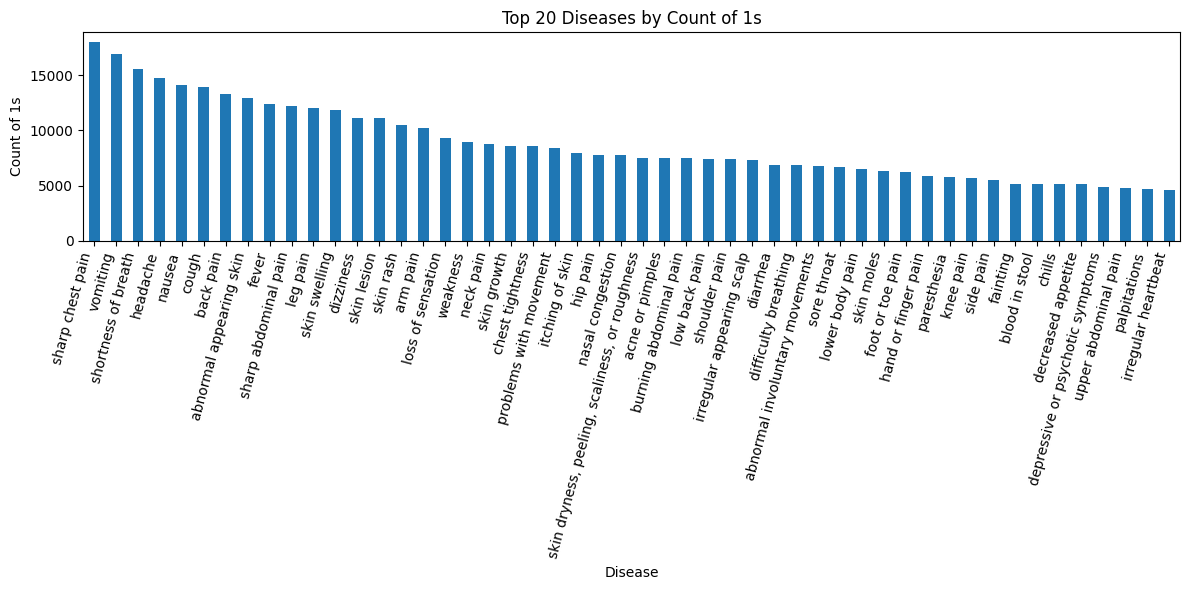

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
top_counts.plot(kind="bar")


plt.title("Top 20 Diseases by Count of 1s")
plt.xlabel("Disease")
plt.ylabel("Count of 1s")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [23]:
least_counts = count_ones.sort_values(ascending=True).head(125)

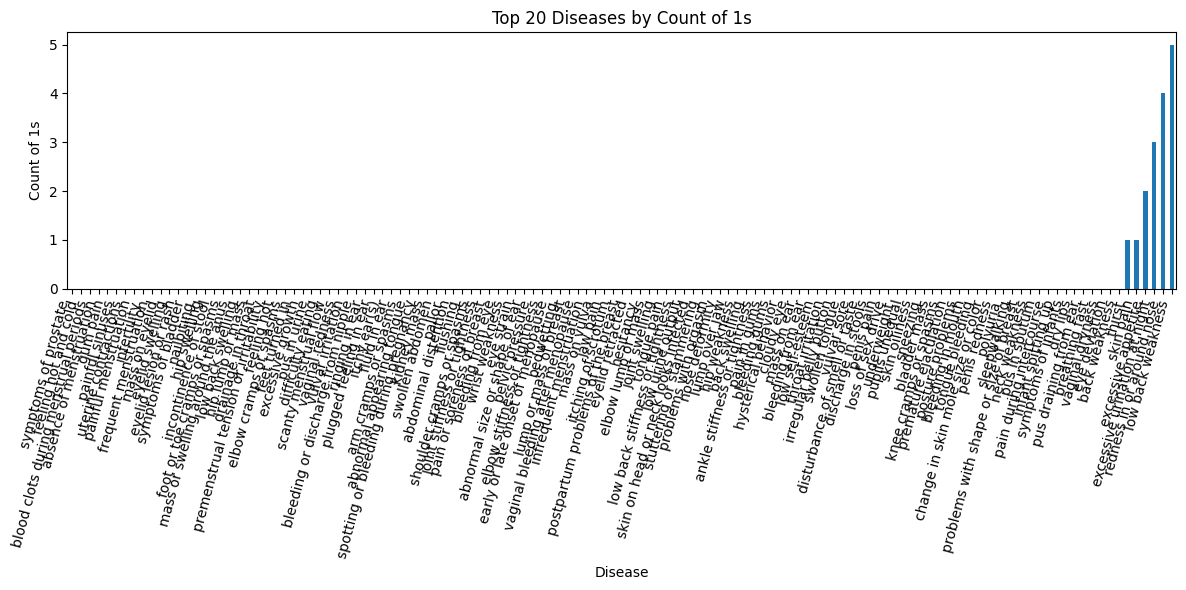

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
least_counts.plot(kind="bar")


plt.title("Top 20 Diseases by Count of 1s")
plt.xlabel("Disease")
plt.ylabel("Count of 1s")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [25]:

# Keep only columns where count > 0
X_filtered = X.loc[:, count_ones > 0]

print("Original shape:", X.shape)

X = X_filtered
print("New shape:", X.shape)

Original shape: (128771, 377)
New shape: (128771, 258)


In [26]:
top_diseases = df['diseases'].value_counts().head(10)
print(top_diseases)

diseases
complex regional pain syndrome    1217
spondylosis                       1216
esophagitis                       1215
hypoglycemia                      1215
peripheral nerve disorder         1215
gastrointestinal hemorrhage       1214
diverticulitis                    1214
acute bronchitis                  1213
pneumonia                         1212
infectious gastroenteritis        1212
Name: count, dtype: int64


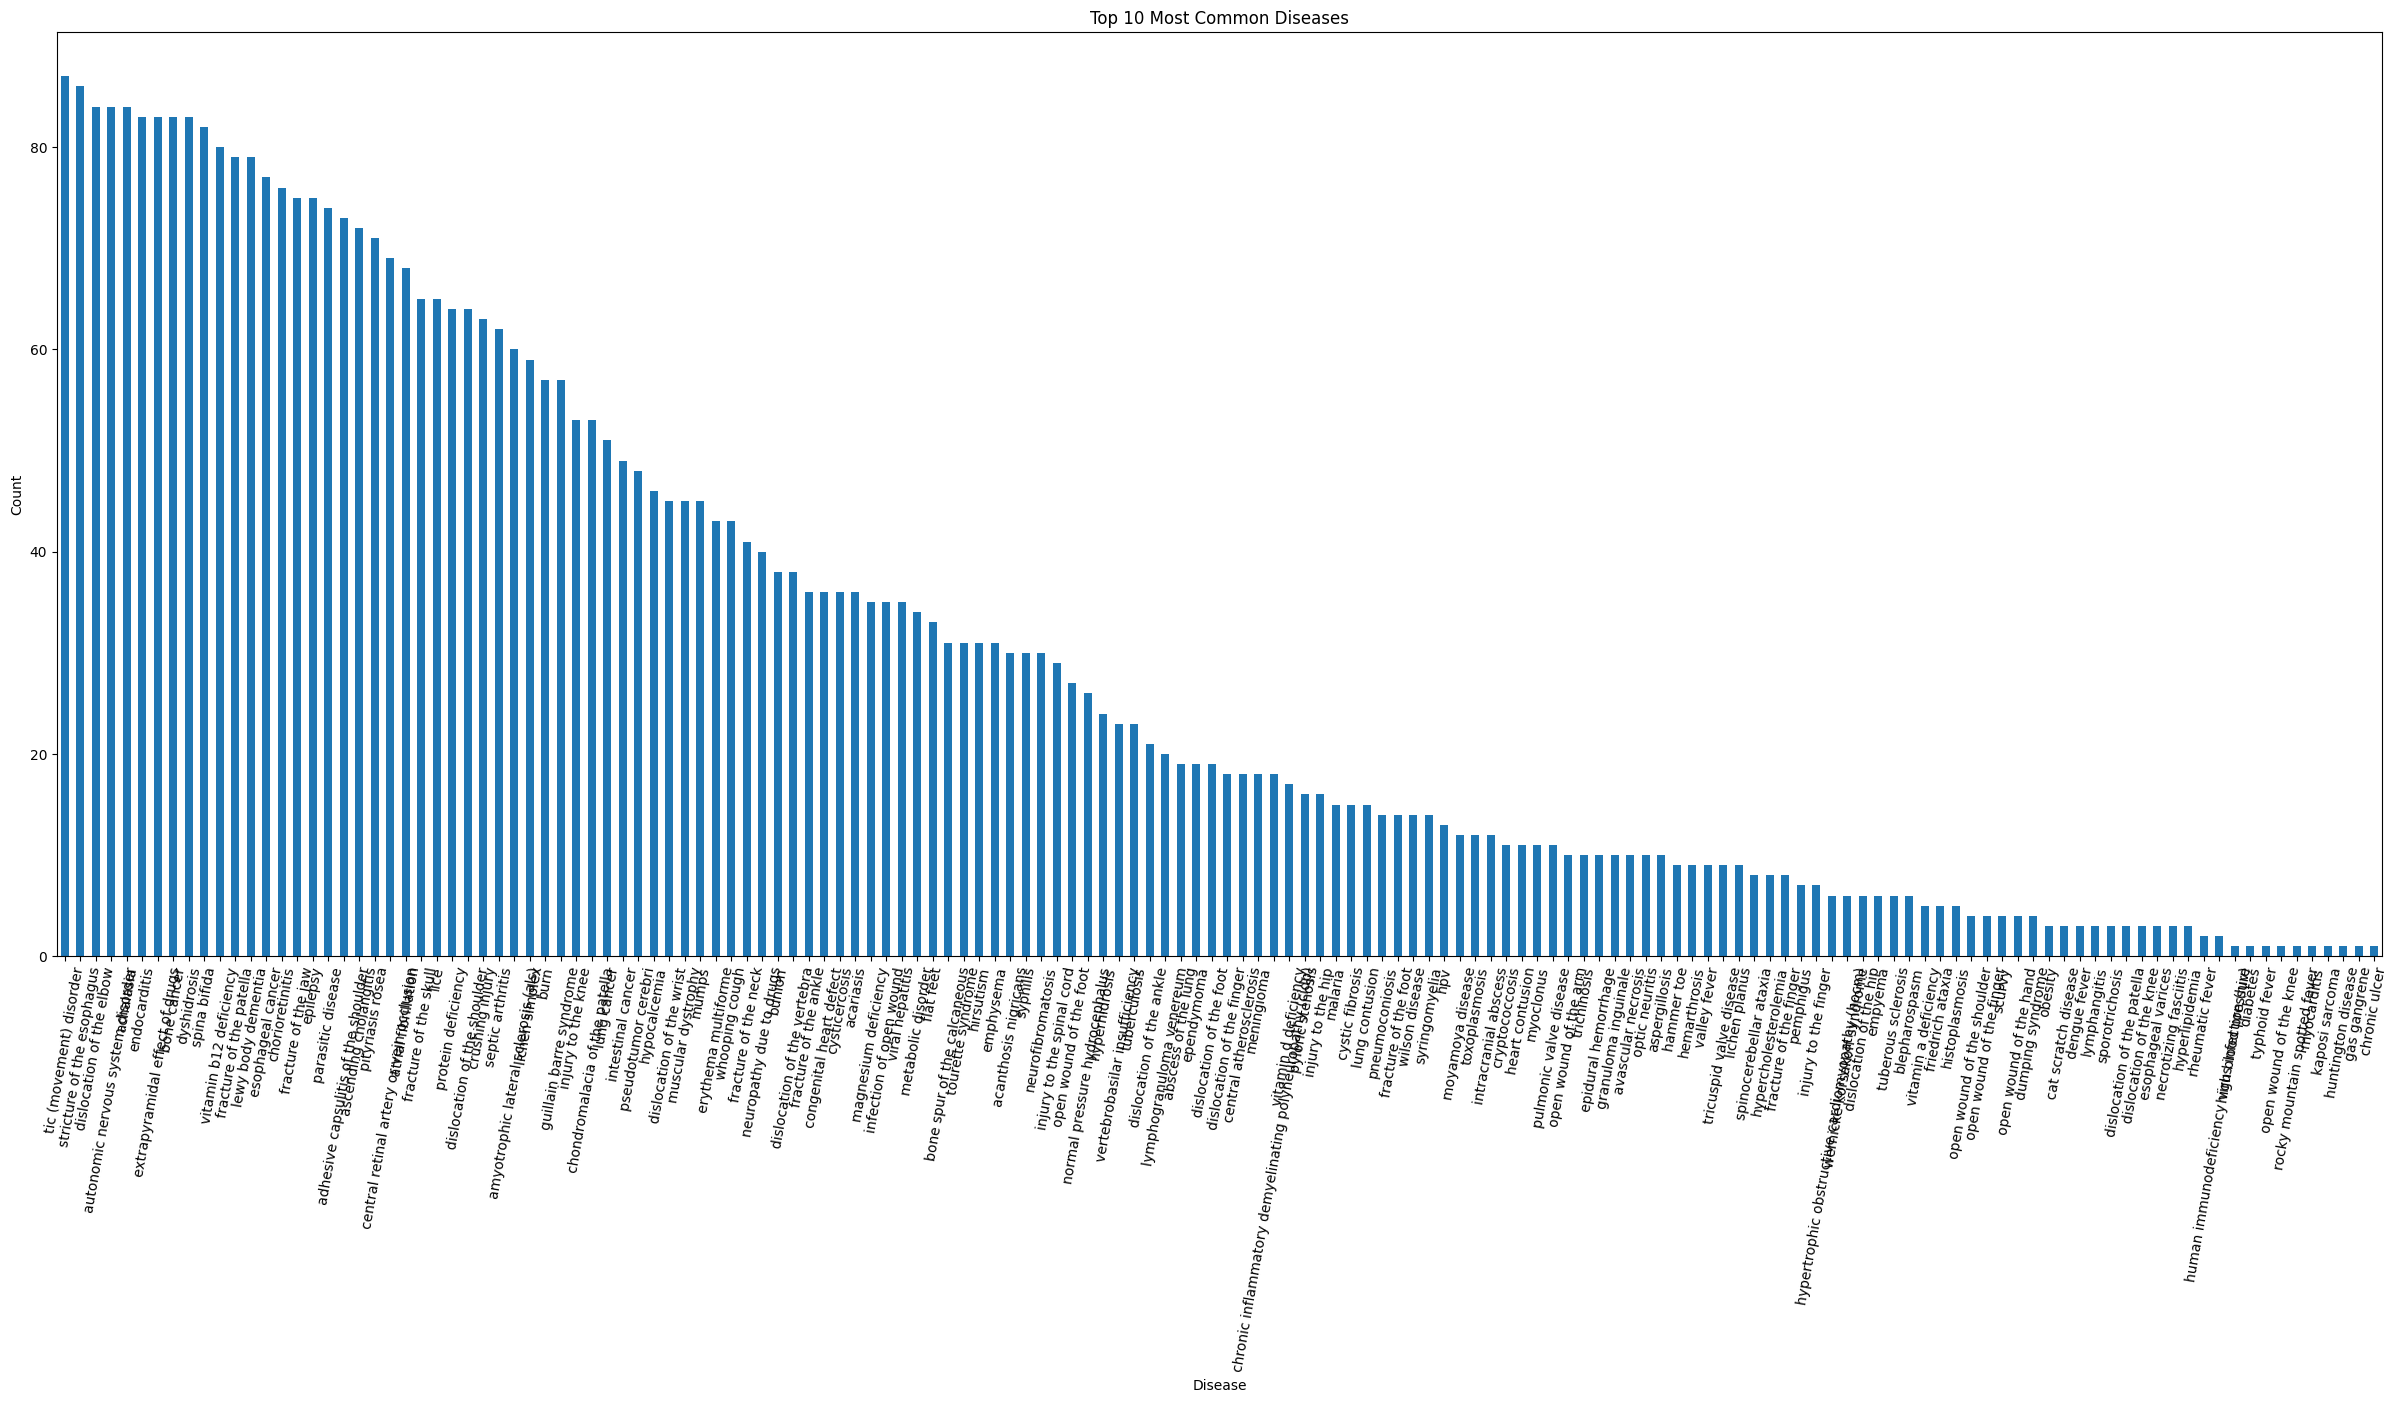

In [27]:
df['diseases'].value_counts().tail(150).plot(kind='bar', figsize=(30,12))
plt.title("Top 10 Most Common Diseases")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=80)
plt.show()

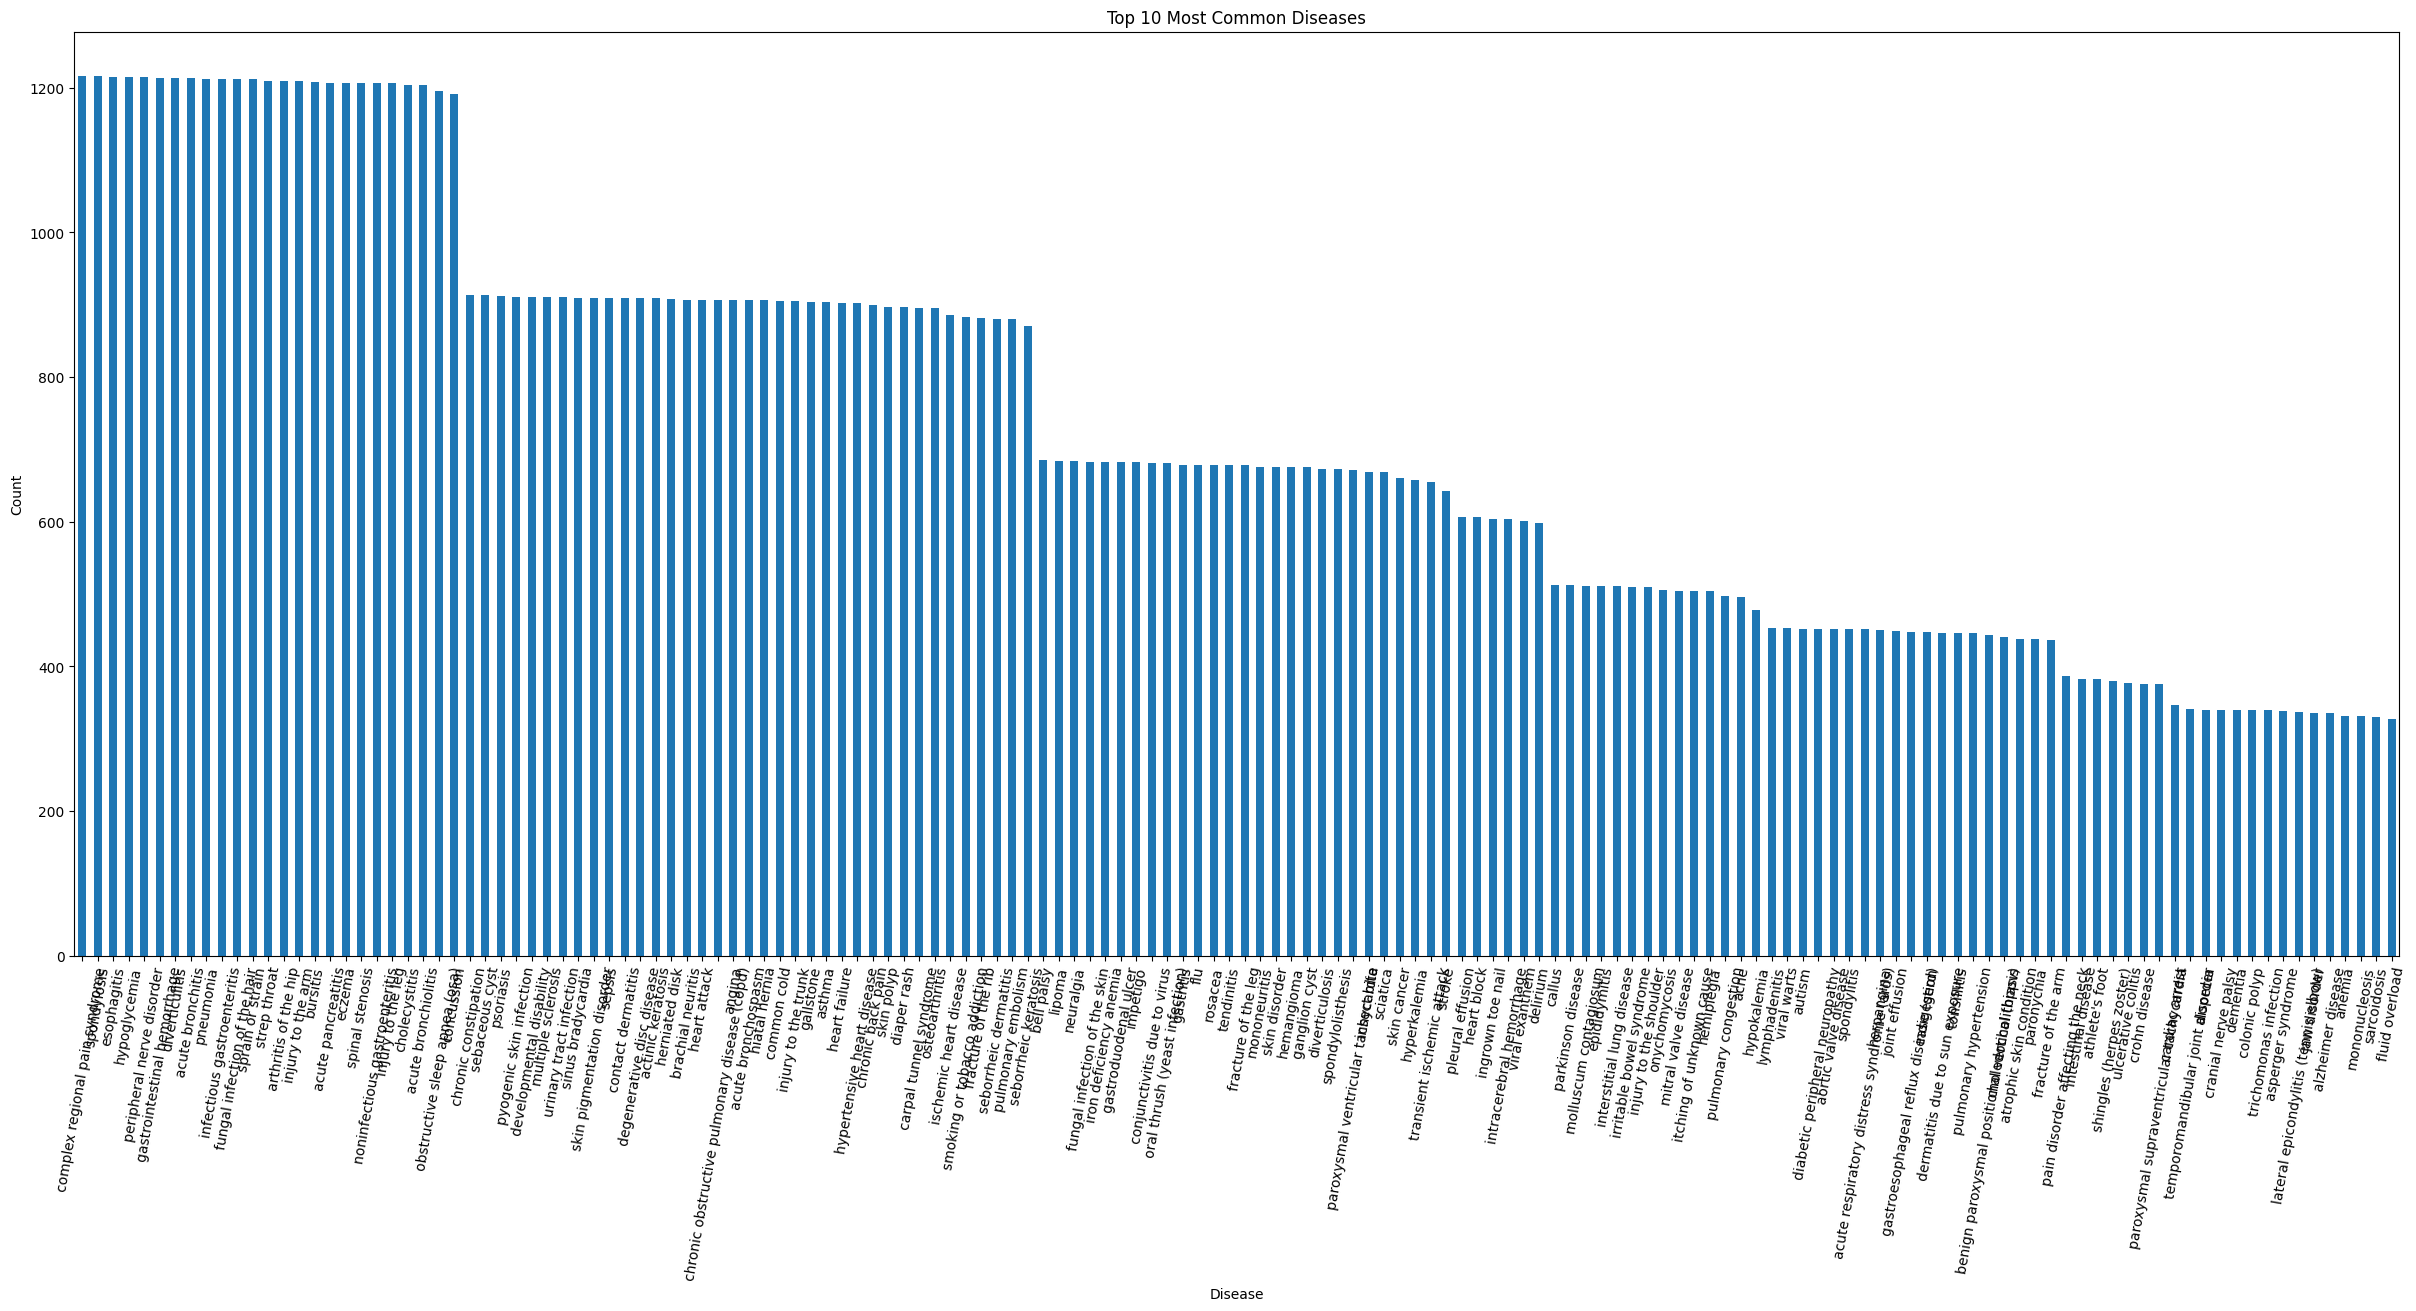

In [28]:
df['diseases'].value_counts().head(150).plot(kind='bar', figsize=(30,12))
plt.title("Top 10 Most Common Diseases")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=80)
plt.show()

In [29]:
# Calculate counts
disease_counts = y.value_counts()

# Get diseases with at least 200 occurrences
valid_diseases = disease_counts[disease_counts >= 200].index

# Filter the dataframe
df_filtered = df[y.isin(valid_diseases)]

print(df_filtered.shape)
print(df_filtered['diseases'].value_counts())

(116055, 378)
diseases
complex regional pain syndrome          1217
spondylosis                             1216
hypoglycemia                            1215
esophagitis                             1215
peripheral nerve disorder               1215
                                        ... 
premature atrial contractions (pacs)     220
lyme disease                             211
osteochondroma                           211
pancreatic cancer                        204
trigeminal neuralgia                     201
Name: count, Length: 178, dtype: int64


In [35]:
df_filtered.columns.tolist()

['diseases',
 'anxiety and nervousness',
 'depression',
 'shortness of breath',
 'depressive or psychotic symptoms',
 'sharp chest pain',
 'dizziness',
 'insomnia',
 'abnormal involuntary movements',
 'chest tightness',
 'palpitations',
 'irregular heartbeat',
 'breathing fast',
 'hoarse voice',
 'sore throat',
 'difficulty speaking',
 'cough',
 'nasal congestion',
 'throat swelling',
 'diminished hearing',
 'lump in throat',
 'throat feels tight',
 'difficulty in swallowing',
 'skin swelling',
 'retention of urine',
 'groin mass',
 'leg pain',
 'hip pain',
 'suprapubic pain',
 'blood in stool',
 'lack of growth',
 'emotional symptoms',
 'elbow weakness',
 'back weakness',
 'pus in sputum',
 'symptoms of the scrotum and testes',
 'swelling of scrotum',
 'pain in testicles',
 'flatulence',
 'pus draining from ear',
 'jaundice',
 'mass in scrotum',
 'white discharge from eye',
 'irritable infant',
 'abusing alcohol',
 'fainting',
 'hostile behavior',
 'drug abuse',
 'sharp abdominal pain

In [59]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [60]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [61]:
y_dt_pred = dt_model.predict(X_test)

In [62]:
print("Accuracy:", accuracy_score(y_test, y_dt_pred)*100)

Accuracy: 83.42619736356754


In [63]:
model = RandomForestClassifier(random_state=42)

In [64]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [65]:
y_pred = model.predict(X_test)

In [66]:
print("Accuracy:" , accuracy_score(y_test , y_pred)*100)

Accuracy: 85.97526645828884


In [67]:
import joblib
from fuzzywuzzy import process
from typing import Dict, List, Union, Tuple

In [68]:
df.to_csv('Training_updated.csv')

In [1]:
from joblib import dump

# Assume `model` is your trained Random Forest model
dump(model, 'rf_disease_model.joblib')

NameError: name 'model' is not defined

In [1]:
from joblib import load

model = load('rf_disease_model.joblib')

In [2]:
pip install python-Levenshtein


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import joblib
import pandas as pd
from typing import Dict, Union
from fuzzywuzzy import process

class DiseasePredictor:
    """Disease predictor with confidence-based specialist routing"""

    def __init__(self, model_path: str, training_data_path: str, disease_department_map: Dict[str, str], severe_diseases: set):
        self.model = joblib.load(model_path)
        self.symptoms_list = self.model.feature_names_in_.tolist()
        self.disease_department_map = disease_department_map
        self.severe_diseases = {s.lower() for s in severe_diseases}

        self.low_conf_threshold = 0.20
        self.mid_conf_threshold = 0.5

    def normalize_symptom(self, symptom: str) -> str:
        """Normalize symptom inputs for matching"""
        return symptom.lower().replace(" ", "_").replace("-", "_").strip()

    def find_best_match(self, user_input: str) -> Union[str, None]:
        normalized = self.normalize_symptom(user_input)
        match, score = process.extractOne(normalized, self.symptoms_list)
        return match if score >= 75 else None

    def encode_symptoms(self, symptoms: list) -> list:
        return [1 if s in symptoms else 0 for s in self.symptoms_list]

    def predict(self, symptoms: list, min_symptoms:int=1, min_confidence:float=0.1, top_n:int=1) -> Dict[str, Dict[str, Union[str, float]]]:
        matched = []
        unrecognized = []
        for symptom in symptoms:
            m = self.find_best_match(symptom)
            if m:
                matched.append(m)
            else:
                unrecognized.append(symptom)
        
        if len(matched) < min_symptoms:
            return {
                "Error": f"At least {min_symptoms} valid symptoms required",
                "details": {
                    "provided": matched,
                    "unrecognized": unrecognized,
                    "suggested": ['fever', 'pain', 'fatigue']
                }
            }
        
        input_vector = self.encode_symptoms(matched)
        probabilities = self.model.predict_proba([input_vector])[0]
        results = {}

        for disease, prob in zip(self.model.classes_, probabilities):
            if prob < min_confidence:
                continue

            confidence = float(prob)
            disease_lower = disease.lower()
            severity = "Severe" if disease_lower in self.severe_diseases else "Mild"

            if confidence < self.low_conf_threshold:
                doctor_level = "General Practitioner"
                department = "General Medicine"
            elif confidence < self.mid_conf_threshold and severity == "Mild":
                doctor_level = "Junior Specialist"
                department = self.disease_department_map.get(disease_lower, 'General Medicine')
            else:
                doctor_level = "Senior Specialist"
                department = self.disease_department_map.get(disease_lower, 'General Medicine')

            results[disease] = {
                "confidence": confidence,
                "department": department,
                "severity": severity,
                "doctor_level": doctor_level,
            }

        if not results:
            return {"Error": "No matching diagnoses found"}

        return dict(sorted(results.items(), key=lambda x: x[1]["confidence"], reverse=True)[:top_n])

    def format_results(self, results: Dict) -> str:
        if "Error" in results:
            message = f"⚠️ {results['Error']}"
            if details := results.get("details"):
                message += f"\n• Recognized symptoms: {details['provided']}"
                message += f"\n• Unrecognized symptoms: {details['unrecognized']}"
                message += f"\n• Try adding symptoms like: {details['suggested']}"
            return message

        output_lines = []
        for disease, info in results.items():
            if info['doctor_level'] == "General Practitioner":
                tier_info = "Low confidence → General Medicine"
            elif info['doctor_level'] == "Junior Specialist":
                tier_info = "Moderate confidence → Junior Specialist"
            else:
                tier_info = "High confidence or Severe disease → Senior Specialist"
                
            output_lines.append(
                f"• {disease} ({info['confidence']*100:.1f}%) — {tier_info}\n"
                f"  Department: {info['department']}\n"
                f"  Severity: {info['severity']}\n"
                f"  Doctor Level: {info['doctor_level']}"
            )            
        return "\n\n".join(output_lines)

In [12]:
if __name__ == "__main__":
    # Define or import your updated disease_department_map dictionary here
    # and the set of severe diseases relevant to your dataset
    disease_department_map = {
    # General Medicine
    'protein deficiency': 'General Medicine',
    'magnesium deficiency': 'General Medicine',
    'scurvy': 'General Medicine',
    'obstructive sleep apnea (osa)': 'Pulmonology',
    'hypertension': 'General Medicine',
    'hyperlipidemia': 'General Medicine',
    'diabetes': 'General Medicine',
    'anemia': 'General Medicine',
    'iron deficiency anemia': 'General Medicine',
    'vitamin b12 deficiency': 'General Medicine',
    'vitamin d deficiency': 'General Medicine',
    'vitamin a deficiency': 'General Medicine',
    'hypokalemia': 'General Medicine',
    'hyperkalemia': 'General Medicine',
    'hypoglycemia': 'General Medicine',
    'fluid overload': 'General Medicine',
    'obesity': 'General Medicine',
    'indigestion': 'Gastroenterology',
    'common cold': 'General Medicine',
    'orthostatic hypotension': 'General Medicine',
    'dehydration': 'General Medicine',
    'narcolepsy': 'Neurology',
    'electrolyte imbalance': 'General Medicine',
    'general fatigue': 'General Medicine',
    'metabolic disorder': 'General Medicine',
    'hypocalcemia': 'General Medicine',
    'hypomagnesemia': 'General Medicine',
    'multiple vitamin deficiencies': 'General Medicine',
    'sepsis': 'Infectious Diseases',
    'mild viral infections': 'Infectious Diseases',
    'acute gastroenteritis': 'Infectious Diseases',
    'chronic fatigue syndrome': 'General Medicine',
    
    # Cardiology
    'heart attack': 'Cardiology',
    'coronary atherosclerosis': 'Cardiology',
    'sick sinus syndrome': 'Cardiology',
    'atrial fibrillation': 'Cardiology',
    'pericarditis': 'Cardiology',
    'mitral valve disease': 'Cardiology',
    'pulmonic valve disease': 'Cardiology',
    'hypertrophic obstructive cardiomyopathy (hocm)': 'Cardiology',
    'atrial flutter': 'Cardiology',
    'premature ventricular contractions (pvcs)': 'Cardiology',
    'paroxysmal ventricular tachycardia': 'Cardiology',
    'angina': 'Cardiology',
    'ischemic heart disease': 'Cardiology',
    'cardiomyopathy': 'Cardiology',
    'heart failure': 'Cardiology',
    'sinus bradycardia': 'Cardiology',
    'central atherosclerosis': 'Cardiology',
    'hypertensive heart disease': 'Cardiology',
    'premature atrial contractions (pacs)': 'Cardiology',
    'tricuspid valve disease': 'Cardiology',
    'heart contusion': 'Cardiology',
    'cardiac arrest': 'Cardiology',
    'heart block': 'Cardiology',

    # Neurology
    'headache after lumbar puncture': 'Neurology',
    'transient ischemic attack': 'Neurology',
    'restless leg syndrome': 'Neurology',
    'stroke': 'Neurology',
    'normal pressure hydrocephalus': 'Neurology',
    'intracranial hemorrhage': 'Neurology',
    'subdural hemorrhage': 'Neurology',
    'cerebral palsy': 'Neurology',
    'myoclonus': 'Neurology',
    'cranial nerve palsy': 'Neurology',
    'concussion': 'Neurology',
    'neuralgia': 'Neurology',
    'chronic inflammatory demyelinating polyneuropathy (cidp)': 'Neurology',
    'myasthenia gravis': 'Neurology',
    'epilepsy': 'Neurology',
    'torticollis': 'Neurology',
    'tension headache': 'Neurology',
    'bell palsy': 'Neurology',
    'hydrocephalus': 'Neurology',
    'encephalitis': 'Neurology',
    'optic neuritis': 'Neurology',
    'hemiplegia': 'Neurology',
    'meningioma': 'Neurology',
    'brain cancer': 'Neurology',
    'syringomyelia': 'Neurology',
    'parkinson disease': 'Neurology',
    'huntington disease': 'Neurology',
    'amyotrophic lateral sclerosis (als)': 'Neurology',
    'autism': 'Neurology',
    'lewy body dementia': 'Neurology',
    'spinal stenosis': 'Neurology',
    'neuropathy due to drugs': 'Neurology',
    'central retinal artery or vein occlusion': 'Neurology',
    'tourette syndrome': 'Neurology',
    'spinocerebellar ataxia': 'Neurology',
    'guillain barre syndrome': 'Neurology',
    'wernicke korsakoff syndrome': 'Neurology',
    'delirium': 'Neurology',
    'lumbago': 'Neurology',
    'brachial neuritis': 'Neurology',
    'peripheral nerve disorder': 'Neurology',
    'muscular dystrophy': 'Neurology',
    'cerebral edema': 'Neurology',
    'migraine': 'Neurology',
    
    # Pulmonology
    'obstructive sleep apnea (osa)': 'Pulmonology',
    'chronic obstructive pulmonary disease (copd)': 'Pulmonology',
    'acute respiratory distress syndrome (ards)': 'Pulmonology',
    'atelectasis': 'Pulmonology',
    'emphysema': 'Pulmonology',
    'asthma': 'Pulmonology',
    'pulmonary eosinophilia': 'Pulmonology',
    'lung contusion': 'Pulmonology',
    'abscess of the lung': 'Pulmonology',
    'pneumonia': 'Pulmonology',
    'pleural effusion': 'Pulmonology',
    'pneumoconiosis': 'Pulmonology',
    'pulmonary fibrosis': 'Pulmonology',
    'acute bronchospasm': 'Pulmonology',
    'lung cancer': 'Pulmonology',
    'interstitial lung disease': 'Pulmonology',
    'acute bronchiolitis': 'Pulmonology',
    'pulmonary hypertension': 'Pulmonology',

    # Gastroenterology
    'pyloric stenosis': 'Gastroenterology',
    'choledocholithiasis': 'Gastroenterology',
    'ischemia of the bowel': 'Gastroenterology',
    'acute pancreatitis': 'Gastroenterology',
    'achalasia': 'Gastroenterology',
    'indigestion': 'Gastroenterology',
    'gastroesophageal reflux disease (gerd)': 'Gastroenterology',
    'colonic polyp': 'Gastroenterology',
    'hiatal hernia': 'Gastroenterology',
    'diverticulosis': 'Gastroenterology',
    'gastroparesis': 'Gastroenterology',
    'gastrointestinal hemorrhage': 'Gastroenterology',
    'gastritis': 'Gastroenterology',
    'esophageal cancer': 'Gastroenterology',
    'esophageal varices': 'Gastroenterology',
    'ulcerative colitis': 'Gastroenterology',
    'intestinal malabsorption': 'Gastroenterology',
    'intestinal disease': 'Gastroenterology',
    'intestinal cancer': 'Gastroenterology',
    'dumping syndrome': 'Gastroenterology',
    'celiac disease': 'Gastroenterology',
    'chronic pancreatitis': 'Gastroenterology',
    'persistent vomiting of unknown cause': 'Gastroenterology',
    'noninfectious gastroenteritis': 'Gastroenterology',
    'gastroparesis': 'Gastroenterology',

    # Infectious Diseases
    'cysticercosis': 'Infectious Diseases',
    'dengue': 'Infectious Diseases',
    'pinworm infection': 'Infectious Diseases',
    'cryptococcosis': 'Infectious Diseases',
    'infectious gastroenteritis': 'Infectious Diseases',
    'mononucleosis': 'Infectious Diseases',
    'gonorrhea': 'Infectious Diseases',
    'syphilis': 'Infectious Diseases',
    'chicken pox': 'Infectious Diseases',
    'typhoid': 'Infectious Diseases',
    'histoplasmosis': 'Infectious Diseases',
    'aspergillosis': 'Infectious Diseases',
    'trichinosis': 'Infectious Diseases',
    'whooping cough': 'Infectious Diseases',
    'malaria': 'Infectious Diseases',
    'cat scratch disease': 'Infectious Diseases',
    'pyogenic skin infection': 'Infectious Diseases',
    'postoperative infection': 'Infectious Diseases',
    'septic arthritis': 'Infectious Diseases',
    'valley fever': 'Infectious Diseases',
    'oral thrush (yeast infection)': 'Infectious Diseases',
    'mild viral infections': 'Infectious Diseases',
    'urinary tract infection': 'Infectious Diseases',
    'molluscum contagiosum': 'Infectious Diseases',
    'necrotizing fasciitis': 'Infectious Diseases',
    'lymphadenitis': 'Infectious Diseases',
    'toxoplasmosis': 'Infectious Diseases',
    'granuloma inguinale': 'Infectious Diseases',
    'herpes zoster (shingles)': 'Infectious Diseases',

    #Dermatology
    'viral warts': 'Dermatology',
    'alopecia': 'Dermatology',
    'actinic keratosis': 'Dermatology',
    'pemphigus': 'Dermatology',
    'psoriasis': 'Dermatology',
    'seborrheic dermatitis': 'Dermatology',
    'fungal infection of the skin': 'Dermatology',
    'eczema': 'Dermatology',
    'itching of unknown cause': 'Dermatology',
    'lichen planus': 'Dermatology',
    'acne': 'Dermatology',
    'dermatitis due to sun exposure': 'Dermatology',
    'sebaceous cyst': 'Dermatology',
    'skin cancer': 'Dermatology',
    'melanoma': 'Dermatology',
    'lichen simplex': 'Dermatology',
    'dyshidrosis': 'Dermatology',
    'pityriasis rosea': 'Dermatology',
    'scabies': 'Dermatology',
    'erythema multiforme': 'Dermatology',
    'impetigo': 'Dermatology',
    'lichen planus': 'Dermatology',
    'psoriasis': 'Dermatology',
    'rosacea': 'Dermatology',
    'diaper rash': 'Dermatology',
    'paronychia': 'Dermatology',
    'molluscum contagiosum': 'Dermatology',
    'sebaceous cyst': 'Dermatology',

    # Orthopedics
    'fracture of the hand': 'Orthopedics',
    'osteochondrosis': 'Orthopedics',
    'injury to the knee': 'Orthopedics',
    'rotator cuff injury': 'Orthopedics',
    'injury to the hand': 'Orthopedics',
    'injury to the hip': 'Orthopedics',
    'fracture of the arm': 'Orthopedics',
    'dislocation of the elbow': 'Orthopedics',
    'spondylosis': 'Orthopedics',
    'injury to the shoulder': 'Orthopedics',
    'bone spur of the calcaneous': 'Orthopedics',
    'injury to the arm': 'Orthopedics',
    'complex regional pain syndrome': 'Orthopedics',
    'injury to the trunk': 'Orthopedics',
    'dislocation of the ankle': 'Orthopedics',
    'plantar fasciitis': 'Orthopedics',
    'fracture of the finger': 'Orthopedics',
    'dislocation of the patella': 'Orthopedics',
    'sciatica': 'Orthopedics',
    'degenerative disc disease': 'Orthopedics',
    'dislocation of the foot': 'Orthopedics',
    'fracture of the shoulder': 'Orthopedics',
    'carpal tunnel syndrome': 'Orthopedics',
    'torticollis': 'Orthopedics',
    'fracture of the rib': 'Orthopedics',
    'fracture of the patella': 'Orthopedics',
    'fracture of the neck': 'Orthopedics',
    'open wound of the shoulder': 'Orthopedics',
    'chronic knee pain': 'Orthopedics',
    'lateral epicondylitis (tennis elbow)': 'Orthopedics',
    'hammer toe': 'Orthopedics',
    'joint effusion': 'Orthopedics',
    'open wound of the knee': 'Orthopedics',
    'fracture of the leg': 'Orthopedics',
    'injury to the leg': 'Orthopedics',
    'tendinitis': 'Orthopedics',
    'arthritis of the hip': 'Orthopedics',
    'osteoarthritis': 'Orthopedics',
    'bursitis': 'Orthopedics',
    'lumbago': 'Orthopedics',
    'scoliosis': 'Orthopedics',
    'trigger finger (finger disorder)': 'Orthopedics',
    'adhesive capsulitis of the shoulder': 'Orthopedics',
    'osteochondroma': 'Orthopedics',
    'avascular necrosis': 'Orthopedics',
    'fracture of the foot': 'Orthopedics',
    'dislocation of the wrist': 'Orthopedics',
    'chondromalacia of the patella': 'Orthopedics',
    'fracture of the vertebra': 'Orthopedics',
    'injury of the ankle': 'Orthopedics',
}

    severe_diseases = {
        'Heart attack',
        'Paralysis (brain hemorrhage)',
        'Pneumonia',
        'Tuberculosis',
        'Peptic ulcer disease',
        'AIDS',
        'Dengue',
        'Typhoid'
        # Add others from your severity list...
        'Cardiac arrest',
        'Heart failure',
        'Stroke',
        'Intracranial hemorrhage',
        'Subdural hemorrhage',
        'Ischemic heart disease',
        'Coronary atherosclerosis',
        'Sepsis',
        'Encephalitis',
        'Brain cancer',
        'Meningioma',      # brain tumor
        'Hydrocephalus',   # can be fatal untreated
        'Amyotrophic lateral sclerosis (als)',
        'Huntington disease',
        'Parkinson disease',   # progressive neurodegenerative
        'Epilepsy',            # severe seizures
        'Guillain barre syndrome',
        'Chronic obstructive pulmonary disease (copd)',
        'Acute respiratory distress syndrome (ards)',
        'Asthma',   # severe cases
        'Pulmonary fibrosis',
        'Lung cancer',
        'Interstitial lung disease',
        'Pulmonary hypertension',
        'Acute pancreatitis',
        'Gastrointestinal hemorrhage',
        'Esophageal cancer',
        'Ulcerative colitis',   # severe cases
        'Chronic pancreatitis',
        'Malaria',
        'Septic arthritis',
        'Necrotizing fasciitis',
        'Herpes zoster (shingles)',   # in severe immunocompromised cases
        'Skin cancer',
        'Melanoma',
        'Osteoarthritis',  # severe disability cases
        'Avascular necrosis',
        'Degenerative disc disease',
    }

        # Initialize predictor instance with model and training data paths
    predictor = DiseasePredictor(
        model_path="rf_disease_model.joblib",
        training_data_path="Training_updated.csv",
        disease_department_map=disease_department_map,
        severe_diseases=severe_diseases
    )

    test_cases = [
        ("muscle_swelling", "knee pain", "limited mobility"),     # Expected: Dengue or similar
        ("fever", "fatigue"),  # Anxiety related
        ("high fever")  # Chicken pox or similar
    ]

    print("🏥 Disease Prediction Test Results 🏥\n")
    for i, symptoms in enumerate(test_cases, 1):
        print(f"🔹 Case {i}: Symptoms = {', '.join(symptoms)}")
        results = predictor.predict(symptoms)
        print(predictor.format_results(results))
        print("-" * 50)


🏥 Disease Prediction Test Results 🏥

🔹 Case 1: Symptoms = muscle_swelling, knee pain, limited mobility
• bone disorder (30.1%) — Moderate confidence → Junior Specialist
  Department: General Medicine
  Severity: Mild
  Doctor Level: Junior Specialist
--------------------------------------------------
🔹 Case 2: Symptoms = fever, fatigue
• vitamin b12 deficiency (29.0%) — Moderate confidence → Junior Specialist
  Department: General Medicine
  Severity: Mild
  Doctor Level: Junior Specialist
--------------------------------------------------
🔹 Case 3: Symptoms = h, i, g, h,  , f, e, v, e, r
• intestinal disease (31.4%) — Moderate confidence → Junior Specialist
  Department: Gastroenterology
  Severity: Mild
  Doctor Level: Junior Specialist
--------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
